# Solar PV Fault Detection Machine Learning Model

In [1]:
#Data Handling
import numpy as np
import pandas as pd 

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#ML libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle

## Load dataset

In [9]:
pv_data = pd.read_excel("C:\\Users\\darsh\\OneDrive\\Desktop\\Machine_learning_projects\\solar_pv_fault_dataset_500.xlsx")
pv_data.head()

,Irradiance,Avg_Temperature,Humidity_%,PV_Current_(A),AC_Voltage_(V),AC_Current_(A),AC_Power_(W),DC_power_(W),Efficiency,avg_voltage,Panel_Class,Efficiency_Loss_%
0,526,38.9375,27.6,5.80,241.63,5.963,1442.4,192.87900,7.478264,33.255,Bird-drop,19.70
1,486,40.1250,31.0,5.53,239.84,5.569,1333.3,180.25035,7.396934,32.595,Bird-drop,16.59
2,131,46.8125,21.1,4.07,228.60,4.150,947.8,130.28070,7.275061,32.010,Clean,0.18
3,27,29.9000,21.3,0.68,230.24,0.775,132.4,24.30660,5.447080,35.745,Clean,1.97
4,627,47.8125,18.0,6.91,243.86,6.465,1575.1,212.37885,7.416464,30.735,Physical-damage,50.08


In [10]:
pv_data.shape

(500, 12)

In [11]:
print(pv_data.describe())
print()
print("Average Irradiance = ",pv_data['Irradiance'].mean())
print()
print("Average Power = ",pv_data['AC_Power_(W)'].mean())
print()
print("Average temperature = ",pv_data['Avg_Temperature'].mean())

       Irradiance  Avg_Temperature  Humidity_%  PV_Current_(A)  \
count  500.000000       500.000000  500.000000      500.000000   
mean   366.368000        43.242525   25.646800        3.912960   
std    263.259278        10.080438    8.830527        2.488692   
min      0.000000        17.050000   12.400000        0.100000   
25%     60.750000        36.278125   18.100000        1.165000   
50%    449.500000        44.675000   24.000000        4.440000   
75%    601.250000        51.209375   31.400000        6.012500   
max    787.000000        85.000000   53.200000        8.450000   

       AC_Voltage_(V)  AC_Current_(A)  AC_Power_(W)  DC_power_(W)  \
count      500.000000      500.000000    500.000000    500.000000   
mean       236.191260        3.580472    854.796600    115.941347   
std         12.382256        2.248104    616.512907     73.932120   
min          0.000000        0.000000      0.000000      0.001500   
25%        231.977500        1.128500    234.575000     35.5

In [12]:
pv_data.columns

Index(['Irradiance', 'Avg_Temperature', 'Humidity_%', 'PV_Current_(A)',
       'AC_Voltage_(V)', 'AC_Current_(A)', 'AC_Power_(W)', 'DC_power_(W)',
       'Efficiency', 'avg_voltage', 'Panel_Class', 'Efficiency_Loss_%'],
      dtype='object')

In [13]:
pv_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Irradiance         500 non-null    int64  
 1   Avg_Temperature    500 non-null    float64
 2   Humidity_%         500 non-null    float64
 3   PV_Current_(A)     500 non-null    float64
 4   AC_Voltage_(V)     500 non-null    float64
 5   AC_Current_(A)     500 non-null    float64
 6   AC_Power_(W)       500 non-null    float64
 7   DC_power_(W)       500 non-null    float64
 8   Efficiency         500 non-null    float64
 9   avg_voltage        500 non-null    float64
 10  Panel_Class        500 non-null    object 
 11  Efficiency_Loss_%  500 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 47.0+ KB


In [14]:
pv_data.isnull().sum()

Irradiance           0
Avg_Temperature      0
Humidity_%           0
PV_Current_(A)       0
AC_Voltage_(V)       0
AC_Current_(A)       0
AC_Power_(W)         0
DC_power_(W)         0
Efficiency           0
avg_voltage          0
Panel_Class          0
Efficiency_Loss_%    0
dtype: int64

## Categorial Feature

In [15]:
print(pv_data.Panel_Class.value_counts())

Panel_Class
Clean                186
Dusty                127
Bird-drop             73
Electrical-damage     47
Physical-damage       40
Snow-covered          27
Name: count, dtype: int64


## converting panel class feature to integer

In [16]:
pv_data.replace({'Panel_Class':{'Clean':0,'Dusty':1,'Bird-drop':2,'Electrical-damage':3,'Physical-damage':4,'Snow-covered':5}},inplace=True)

C:\Users\darsh\AppData\Local\Temp\ipykernel_14620\976558928.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pv_data.replace({'Panel_Class':{'Clean':0,'Dusty':1,'Bird-drop':2,'Electrical-damage':3,'Physical-damage':4,'Snow-covered':5}},inplace=True)


In [17]:
pv_data.head()

,Irradiance,Avg_Temperature,Humidity_%,PV_Current_(A),AC_Voltage_(V),AC_Current_(A),AC_Power_(W),DC_power_(W),Efficiency,avg_voltage,Panel_Class,Efficiency_Loss_%
0,526,38.9375,27.6,5.80,241.63,5.963,1442.4,192.87900,7.478264,33.255,2,19.70
1,486,40.1250,31.0,5.53,239.84,5.569,1333.3,180.25035,7.396934,32.595,2,16.59
2,131,46.8125,21.1,4.07,228.60,4.150,947.8,130.28070,7.275061,32.010,0,0.18
3,27,29.9000,21.3,0.68,230.24,0.775,132.4,24.30660,5.447080,35.745,0,1.97
4,627,47.8125,18.0,6.91,243.86,6.465,1575.1,212.37885,7.416464,30.735,4,50.08


## Data Visualization

### 1. Fault Distribution

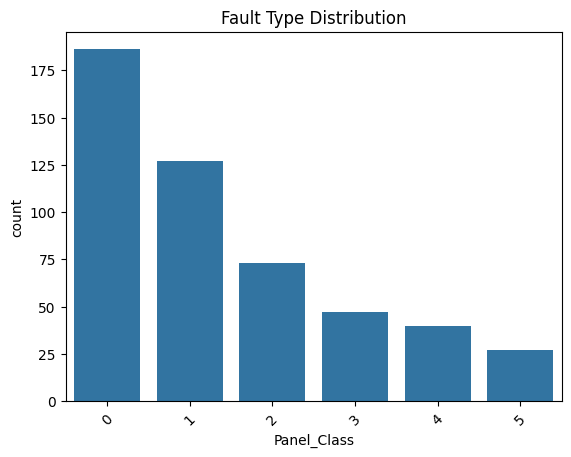

In [18]:
plt.Figure(figsize=(8,5))
sns.countplot(x='Panel_Class',data=pv_data)
plt.xticks(rotation=45)
plt.title("Fault Type Distribution")
plt.show()

### 2. Irradiance vs Power

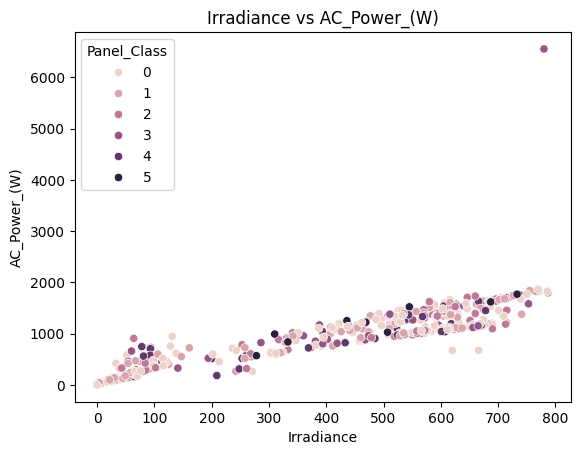

In [19]:
plt.Figure(figsize=(8,5))
sns.scatterplot(x="Irradiance",y="AC_Power_(W)", hue='Panel_Class',data=pv_data)
plt.title("Irradiance vs AC_Power_(W)")
plt.show()


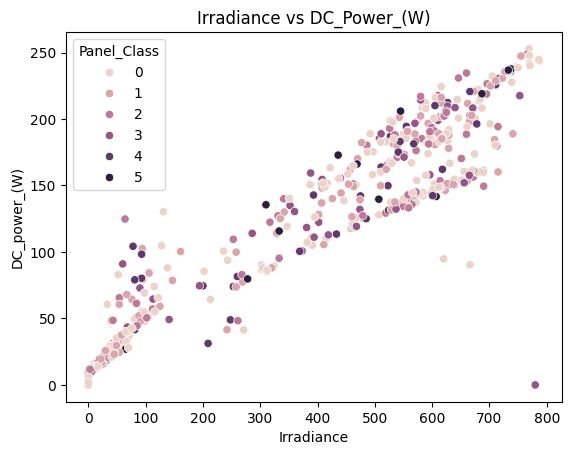

In [20]:
plt.Figure(figsize=(8,5))
sns.scatterplot(x="Irradiance",y="DC_power_(W)", hue='Panel_Class',data=pv_data)
plt.title("Irradiance vs DC_Power_(W)")
plt.show()


### Correlation Heatmap

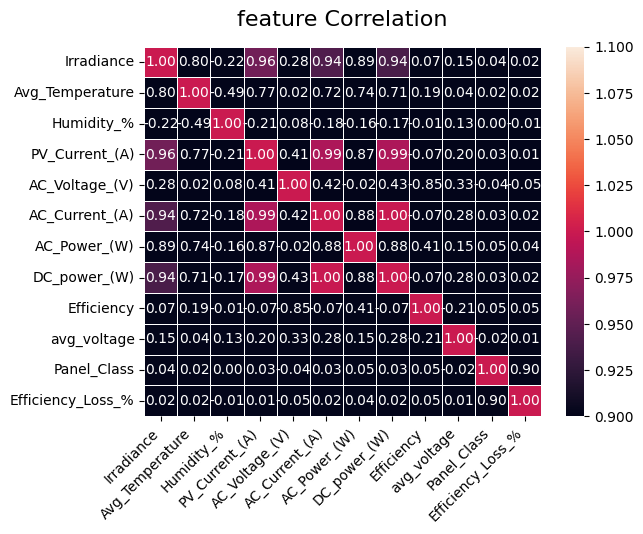

In [21]:
plt.Figure(figsize=(10,7))
sns.heatmap(pv_data.corr(numeric_only=True),annot=True,fmt=".2f",linewidths=0.5,vmin=1,vmax=1)
plt.title("feature Correlation",fontsize=16,pad=15)
plt.xticks(rotation=45, ha='right')
plt.show()

## Feature Selection
### Target variable: panel_class
###   Input features:  Irradiance,Temperature,Humidity,Power,Current,Voltage

In [22]:
X = pv_data.drop('Panel_Class',axis=1)
Y = pv_data['Panel_Class']

In [23]:
model = RandomForestClassifier()

In [24]:
model.fit(X,Y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=42)


In [26]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(350, 11)
(150, 11)
(350,)
(150,)


In [27]:
model = RandomForestClassifier()
model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = model.predict(X_test)

In [29]:
accuracy = accuracy_score(Y_test,y_pred)
print("Model Accuracy = ", accuracy)

Model Accuracy =  0.7666666666666667


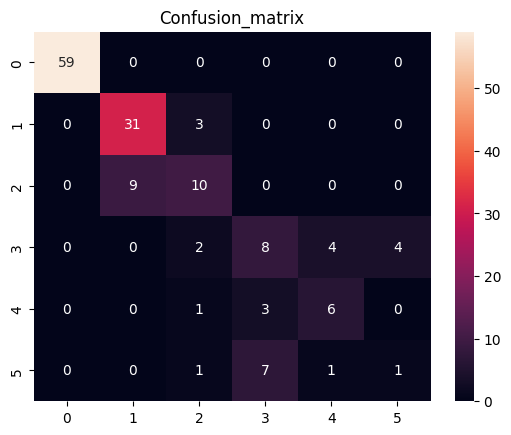

In [30]:
cm = confusion_matrix(Y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion_matrix")
plt.show()


In [31]:
report = classification_report(Y_test,y_pred)
print("report = ", report)

report =                precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       0.78      0.91      0.84        34
           2       0.59      0.53      0.56        19
           3       0.44      0.44      0.44        18
           4       0.55      0.60      0.57        10
           5       0.20      0.10      0.13        10

    accuracy                           0.77       150
   macro avg       0.59      0.60      0.59       150
weighted avg       0.75      0.77      0.75       150



In [32]:
with open("solar_fault_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [33]:
import pickle

pickle.dump(accuracy, open("accuracy.pkl", "wb"))